# AI Contextual Explainer

AI menjelaskan konsep teknis aplikasi menggunakan bahasa dan analogi yang familiar bagi pengguna MSME pedesaan ASEAN. Model SLM (Small Language Model) menghasilkan penjelasan yang relevan dengan konteks pekerjaan pengguna, sehingga fitur-fitur kompleks menjadi mudah dipahami.

**Konsep Utama:**
- Input: Konsep teknis / fitur aplikasi yang perlu dijelaskan
- Output: Penjelasan sederhana dengan analogi dari kehidupan sehari-hari pengguna

Occupation Categories:
- farmer -> Petani (padi, sayur, buah)
- livestock_owner -> Peternak (sapi, kambing, unggas)
- fisherman -> Nelayan (tangkap, budidaya)
- trader -> Pedagang (warung, pasar, keliling)
- craftsman -> Pengrajin (kayu, anyaman, tekstil)
- youth -> Pemuda (pekerja harian, gig worker)
- plantation_worker -> Pekerja kebun (sawit, karet, kopi)
- daily_laborer -> Buruh harian (bangunan, angkut)

Model List:
- Qwen2.5-3B-Instruct GGUF Q4_K_M (~2.0 GB)
- Qwen2.5-1.5B-Instruct GGUF Q4_K_M (~1.1 GB)
- Qwen2.5-0.5B-Instruct GGUF Q4_K_M (~491 MB)

# Data Generation

## Setup

### Environment Setup

In [31]:
!pip install transformers accelerate huggingface_hub llama-cpp-python

In [32]:
import numpy as np
import pandas as pd
import json
import os
import time
import warnings
import textwrap
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

### Configuration

In [33]:
"""
Global configuration untuk Contextual Explainer.
"""

config = {
    'random_seed': 42,

    'model_id': 'Qwen/Qwen2.5-0.5B-Instruct',
    'model_name': 'Qwen2.5-0.5B-Instruct',
    'gguf_repo': 'Qwen/Qwen2.5-0.5B-Instruct-GGUF',
    'gguf_filename': 'qwen2.5-0.5b-instruct-q4_k_m.gguf',

    'fallback_model_id': 'Qwen/Qwen2.5-1.5B-Instruct',
    'fallback_gguf_repo': 'Qwen/Qwen2.5-1.5B-Instruct-GGUF',
    'fallback_gguf_filename': 'qwen2.5-1.5b-instruct-q4_k_m.gguf',

    'model_3b_id': 'Qwen/Qwen2.5-3B-Instruct',
    'model_3b_name': 'Qwen2.5-3B-Instruct',
    'model_3b_gguf_repo': 'Qwen/Qwen2.5-3B-Instruct-GGUF',
    'model_3b_gguf_filename': 'qwen2.5-3b-instruct-q4_k_m.gguf',

    'generation': {
        'max_new_tokens': 150,
        'temperature': 0.4,
        'top_p': 0.9,
        'top_k': 40,
        'repetition_penalty': 1.1,
        'do_sample': True
    },

    'gguf_params': {
        'n_ctx': 2048,
        'n_threads': 4,
        'n_batch': 64,
        'verbose': False
    },

    'occupation_categories': [
        'farmer',
        'livestock_owner',
        'fisherman',
        'trader',
        'craftsman',
        'youth',
        'plantation_worker',
        'daily_laborer'
    ],

    'occupation_labels': {
        'farmer': 'Petani',
        'livestock_owner': 'Peternak',
        'fisherman': 'Nelayan',
        'trader': 'Pedagang',
        'craftsman': 'Pengrajin',
        'youth': 'Pemuda / Pekerja Gig',
        'plantation_worker': 'Pekerja Kebun',
        'daily_laborer': 'Buruh Harian'
    }
}

np.random.seed(config['random_seed'])

f"Configuration loaded: {len(config['occupation_categories'])} occupation categories, model={config['model_name']}"

'Configuration loaded: 8 occupation categories, model=Qwen2.5-0.5B-Instruct'

### Path Setup

In [34]:
"""Base path untuk Google Drive storage"""
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon'
datas_path = f'{base_path}/datas'
models_path = f'{base_path}/models/ai-dialect-translator'
gguf_path = models_path

Path(f'{datas_path}').mkdir(parents=True, exist_ok=True)
Path(f'{models_path}').mkdir(parents=True, exist_ok=True)
Path(f'{gguf_path}').mkdir(parents=True, exist_ok=True)

print(f"datas_path: {datas_path}")
print(f"models_path: {models_path}")
print(f"gguf_path: {gguf_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
datas_path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas
models_path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator
gguf_path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator


## Occupation Profiles

In [35]:
"""
Definisi profil occupation beserta konteks domain, kata kunci, gaya penjelasan,
dan pasangan contoh (example_concept + example_explanation) untuk few-shot prompting.
"""

occupation_profiles = {
    'farmer': {
        'label': 'Petani',
        'domain_keywords': ['panen', 'lahan', 'pupuk', 'musim', 'bibit', 'sawah', 'ladang', 'irigasi', 'tanam', 'gabah'],
        'typical_context': 'Bekerja di sawah/ladang, mengikuti musim tanam, menjual hasil panen ke tengkulak atau pasar',
        'explanation_style': 'Menggunakan analogi pertanian: musim, panen, bibit, lahan, pupuk',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti Pak Lurah yang tahu siapa di desa ini yang rajin bayar iuran dan siapa yang suka bantu tetangga panen. Aplikasi ini juga mengingat kerajinan Bapak mencatat hasil panen dan bayar cicilan tepat waktu. Dari situ bisa tahu layak dapat pinjaman atau tidak.'
    },
    'livestock_owner': {
        'label': 'Peternak',
        'domain_keywords': ['ternak', 'sapi', 'kambing', 'unggas', 'pakan', 'kandang', 'vaksin', 'breeding', 'susu', 'daging'],
        'typical_context': 'Memelihara hewan ternak, menjual ke koperasi atau pasar hewan, mengurus kesehatan ternak',
        'explanation_style': 'Menggunakan analogi peternakan: ternak, kandang, pakan, koperasi',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti ketika koperasi mau beli sapi dari Bapak, mereka lihat dulu ternak Bapak sehat tidak, kandangnya bersih tidak, vaksinnya rutin tidak. Aplikasi ini juga menilai dari kerajinan Bapak mencatat penjualan ternak dan bayar cicilan. Kalau bagus, pinjaman bisa lebih besar.'
    },
    'fisherman': {
        'label': 'Nelayan',
        'domain_keywords': ['ikan', 'jala', 'perahu', 'laut', 'tangkapan', 'TPI', 'musim_ikan', 'tambak', 'udang', 'dermaga'],
        'typical_context': 'Melaut mencari ikan, menjual hasil tangkapan di TPI, merawat perahu dan alat tangkap',
        'explanation_style': 'Menggunakan analogi kelautan: laut, tangkapan, jala, perahu, musim ikan',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti juragan TPI yang tahu nelayan mana yang rajin melaut dan selalu bayar hutang solar tepat waktu. Aplikasi ini juga mencatat kerajinan Bapak mencatat hasil tangkapan dan bayar cicilan. Nelayan yang terpercaya bisa dapat pinjaman lebih besar untuk beli jala baru.'
    },
    'trader': {
        'label': 'Pedagang',
        'domain_keywords': ['dagangan', 'warung', 'modal', 'untung', 'rugi', 'stok', 'pelanggan', 'pasar', 'harga', 'kulakan'],
        'typical_context': 'Menjalankan warung atau berdagang di pasar, mengelola stok dan arus kas harian',
        'explanation_style': 'Menggunakan analogi perdagangan: modal, untung, stok, pelanggan, warung',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti supplier yang mau kasih barang tempo, mereka lihat dulu toko Ibu lancar tidak bayarnya, pelanggannya banyak tidak. Aplikasi ini juga menilai dari catatan dagangan dan pembayaran Ibu. Kalau bagus reputasinya, bisa dapat modal lebih besar.'
    },
    'craftsman': {
        'label': 'Pengrajin',
        'domain_keywords': ['kerajinan', 'anyaman', 'kayu', 'ukiran', 'pesanan', 'bahan_baku', 'finishing', 'motif', 'tekstil', 'jahit'],
        'typical_context': 'Membuat kerajinan tangan, menerima pesanan, mengelola bahan baku dan produksi',
        'explanation_style': 'Menggunakan analogi kerajinan: pesanan, bahan baku, finishing, motif',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti pembeli besar yang mau pesan anyaman banyak, mereka lihat dulu hasil kerja Ibu bagus tidak, pesanan sebelumnya tepat waktu tidak. Aplikasi ini juga menilai dari catatan pesanan dan pembayaran Ibu. Pengrajin yang terpercaya bisa dapat modal lebih besar untuk beli bahan baku.'
    },
    'youth': {
        'label': 'Pemuda / Pekerja Gig',
        'domain_keywords': ['kerja_harian', 'mandor', 'borongan', 'upah', 'shift', 'freelance', 'ojek', 'proyek', 'skill', 'pelatihan'],
        'typical_context': 'Mencari kerja harian lewat mandor, kerja borongan atau freelance, membangun skill',
        'explanation_style': 'Menggunakan analogi kerja harian: mandor, borongan, upah, proyek, skill',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti mandor yang tahu siapa pekerja yang rajin dan bisa diandalkan, dari situ dia kasih proyek yang lebih besar. Aplikasi ini juga mencatat kerajinan kamu menabung dan bayar cicilan. Kalau bagus reputasinya, bisa dapat pinjaman untuk beli HP baru atau bayar pelatihan skill.'
    },
    'plantation_worker': {
        'label': 'Pekerja Kebun',
        'domain_keywords': ['kebun', 'sawit', 'karet', 'kopi', 'getah', 'panen_raya', 'mandor_kebun', 'timbangan', 'TBS', 'sadap'],
        'typical_context': 'Bekerja di perkebunan besar, memanen TBS sawit atau menyadap karet, ditimbang hasil kerjanya',
        'explanation_style': 'Menggunakan analogi perkebunan: kebun, panen, timbangan, mandor, getah',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti mandor kebun yang tahu siapa pekerja yang rajin dan hasil panennya selalu bagus di timbangan. Aplikasi ini juga mencatat kerajinan Bapak menabung dari gaji dan bayar cicilan tepat waktu. Pekerja yang terpercaya bisa dapat pinjaman lebih besar.'
    },
    'daily_laborer': {
        'label': 'Buruh Harian',
        'domain_keywords': ['bangunan', 'angkut', 'kuli', 'tukang', 'proyek', 'upah_harian', 'mandor', 'material', 'cor', 'bata'],
        'typical_context': 'Bekerja di proyek bangunan atau angkutan, dibayar harian, mengikuti arahan mandor',
        'explanation_style': 'Menggunakan analogi pekerjaan kasar: proyek, material, mandor, upah harian',
        'example_concept': 'Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna.',
        'example_explanation': 'Seperti mandor proyek yang tahu siapa tukang yang rajin kerja dan tidak pernah bolos. Dari situ mandor kasih kerja terus di proyek berikutnya. Aplikasi ini juga mencatat kerajinan Bapak menabung dan bayar cicilan. Kalau bagus, bisa dapat pinjaman untuk beli alat kerja.'
    }
}

occupation_df = pd.DataFrame([
    {
        'occupation_id': occ_id,
        'occupation_label': profile['label'],
        'domain_keywords': ', '.join(profile['domain_keywords']),
        'typical_context': profile['typical_context'],
        'explanation_style': profile['explanation_style'],
        'example_concept': profile['example_concept'],
        'example_explanation': profile['example_explanation']
    }
    for occ_id, profile in occupation_profiles.items()
])

print(f"Generated {len(occupation_df)} occupation profiles")
occupation_df

Generated 8 occupation profiles


,occupation_id,occupation_label,domain_keywords,typical_context,explanation_style,example_concept,example_explanation
0,farmer,Petani,"panen, lahan, pupuk, musim, bibit, sawah, lada...","Bekerja di sawah/ladang, mengikuti musim tanam...","Menggunakan analogi pertanian: musim, panen, b...",Credit scoring adalah sistem yang menilai kela...,Seperti Pak Lurah yang tahu siapa di desa ini ...
1,livestock_owner,Peternak,"ternak, sapi, kambing, unggas, pakan, kandang,...","Memelihara hewan ternak, menjual ke koperasi a...","Menggunakan analogi peternakan: ternak, kandan...",Credit scoring adalah sistem yang menilai kela...,Seperti ketika koperasi mau beli sapi dari Bap...
2,fisherman,Nelayan,"ikan, jala, perahu, laut, tangkapan, TPI, musi...","Melaut mencari ikan, menjual hasil tangkapan d...","Menggunakan analogi kelautan: laut, tangkapan,...",Credit scoring adalah sistem yang menilai kela...,Seperti juragan TPI yang tahu nelayan mana yan...
3,trader,Pedagang,"dagangan, warung, modal, untung, rugi, stok, p...","Menjalankan warung atau berdagang di pasar, me...","Menggunakan analogi perdagangan: modal, untung...",Credit scoring adalah sistem yang menilai kela...,"Seperti supplier yang mau kasih barang tempo, ..."
4,craftsman,Pengrajin,"kerajinan, anyaman, kayu, ukiran, pesanan, bah...","Membuat kerajinan tangan, menerima pesanan, me...","Menggunakan analogi kerajinan: pesanan, bahan ...",Credit scoring adalah sistem yang menilai kela...,Seperti pembeli besar yang mau pesan anyaman b...
5,youth,Pemuda / Pekerja Gig,"kerja_harian, mandor, borongan, upah, shift, f...","Mencari kerja harian lewat mandor, kerja boron...","Menggunakan analogi kerja harian: mandor, boro...",Credit scoring adalah sistem yang menilai kela...,Seperti mandor yang tahu siapa pekerja yang ra...
6,plantation_worker,Pekerja Kebun,"kebun, sawit, karet, kopi, getah, panen_raya, ...","Bekerja di perkebunan besar, memanen TBS sawit...","Menggunakan analogi perkebunan: kebun, panen, ...",Credit scoring adalah sistem yang menilai kela...,Seperti mandor kebun yang tahu siapa pekerja y...
7,daily_laborer,Buruh Harian,"bangunan, angkut, kuli, tukang, proyek, upah_h...","Bekerja di proyek bangunan atau angkutan, diba...","Menggunakan analogi pekerjaan kasar: proyek, m...",Credit scoring adalah sistem yang menilai kela...,Seperti mandor proyek yang tahu siapa tukang y...


## Application Texts

In [36]:
"""
Setiap entry memiliki text_id, feature_source (fitur asal), dan concept_text.
Konsep ini akan dijelaskan oleh model dengan bahasa yang sesuai occupation pengguna.
"""

app_texts = [
    {
        'text_id': 'credit_01',
        'feature_source': 'AI Credit Scoring',
        'concept_text': 'Credit scoring menganalisis pola transaksi, frekuensi pencatatan keuangan, dan jaringan sosial Anda untuk menentukan skor kelayakan pinjaman. Semakin tinggi skor, semakin besar pinjaman yang bisa diajukan.',
        'context_hint': 'Penjelasan cara kerja credit scoring'
    },
    {
        'text_id': 'credit_02',
        'feature_source': 'AI Credit Scoring',
        'concept_text': 'Skor kredit Anda dihitung dari beberapa faktor: konsistensi mencatat pemasukan/pengeluaran, ketepatan waktu membayar cicilan, dan reputasi teman-teman di jaringan sosial Anda.',
        'context_hint': 'Faktor yang mempengaruhi skor kredit'
    },
    {
        'text_id': 'credit_03',
        'feature_source': 'AI Credit Scoring',
        'concept_text': 'Riwayat kredit positif akan tersimpan dan bisa digunakan sebagai referensi untuk pengajuan pinjaman berikutnya, baik di aplikasi ini maupun lembaga keuangan lain.',
        'context_hint': 'Manfaat membangun riwayat kredit'
    },
    {
        'text_id': 'match_01',
        'feature_source': 'AI Opportunity Matching',
        'concept_text': 'Fitur opportunity matching menggunakan AI untuk mencocokkan profil usaha Anda dengan peluang pasar, program bantuan pemerintah, atau koperasi yang sesuai dengan lokasi dan jenis usaha Anda.',
        'context_hint': 'Cara kerja opportunity matching'
    },
    {
        'text_id': 'match_02',
        'feature_source': 'AI Opportunity Matching',
        'concept_text': 'Algoritma rekomendasi mempelajari pola transaksi dan preferensi Anda untuk menyarankan waktu terbaik menjual produk berdasarkan fluktuasi harga pasar historis.',
        'context_hint': 'Rekomendasi waktu jual'
    },
    {
        'text_id': 'sync_01',
        'feature_source': 'Delay Tolerant Sync',
        'concept_text': 'Mode offline memungkinkan Anda tetap menggunakan aplikasi tanpa internet. Semua data disimpan lokal dan otomatis tersinkronisasi ke server ketika koneksi tersedia, tanpa kehilangan data.',
        'context_hint': 'Cara kerja mode offline'
    },
    {
        'text_id': 'sync_02',
        'feature_source': 'Delay Tolerant Sync',
        'concept_text': 'Sinkronisasi tertunda menggunakan teknologi store-and-forward: data dikemas, dienkripsi, dan dikirim secara otomatis saat sinyal tersedia. Proses ini transparan dan tidak perlu intervensi pengguna.',
        'context_hint': 'Mekanisme store-and-forward'
    },
    {
        'text_id': 'ars_01',
        'feature_source': 'Adaptive Readiness System',
        'concept_text': 'Dashboard keuangan menampilkan ringkasan pendapatan, pengeluaran, dan tren bulanan dalam bentuk grafik sederhana. Fitur ini membantu Anda melihat pola keuangan dan membuat keputusan lebih baik.',
        'context_hint': 'Fungsi dashboard keuangan'
    },
    {
        'text_id': 'ars_02',
        'feature_source': 'Adaptive Readiness System',
        'concept_text': 'Proyeksi keuangan menggunakan data historis Anda untuk memperkirakan pendapatan di bulan-bulan mendatang. Ini membantu merencanakan pengeluaran besar atau persiapan musim paceklik.',
        'context_hint': 'Cara kerja proyeksi keuangan'
    },
    {
        'text_id': 'ars_03',
        'feature_source': 'Adaptive Readiness System',
        'concept_text': 'Fitur budgeting otomatis menyarankan alokasi pendapatan ke pos-pos pengeluaran berdasarkan pola belanja Anda sebelumnya, termasuk saran menyisihkan dana darurat.',
        'context_hint': 'Fitur budgeting otomatis'
    },
    {
        'text_id': 'safety_01',
        'feature_source': 'Safe Mode Simulation',
        'concept_text': 'Mode latihan adalah lingkungan aman untuk mencoba semua fitur aplikasi tanpa konsekuensi nyata. Data yang dimasukkan tidak akan tersimpan atau dikirim ke server.',
        'context_hint': 'Fungsi mode latihan'
    },
    {
        'text_id': 'safety_02',
        'feature_source': 'Safe Mode Simulation',
        'concept_text': 'Dalam mode latihan, Anda bisa bereksperimen dengan pengajuan pinjaman, pencatatan transaksi, atau fitur lainnya. Ini membantu memahami cara kerja aplikasi sebelum menggunakannya secara nyata.',
        'context_hint': 'Manfaat mode latihan'
    },
    {
        'text_id': 'privacy_01',
        'feature_source': 'Privacy & Security',
        'concept_text': 'Enkripsi end-to-end melindungi data keuangan Anda. Data dienkripsi di perangkat sebelum dikirim, sehingga hanya Anda yang bisa mengaksesnya. Bahkan operator server tidak bisa membaca data Anda.',
        'context_hint': 'Cara kerja enkripsi'
    },
    {
        'text_id': 'privacy_02',
        'feature_source': 'Privacy & Security',
        'concept_text': 'Verifikasi dua langkah menambah lapisan keamanan. Selain password, Anda perlu konfirmasi dari SMS atau sidik jari untuk login. Ini mencegah orang lain mengakses akun meskipun tahu password.',
        'context_hint': 'Cara kerja 2FA'
    },
    {
        'text_id': 'network_01',
        'feature_source': 'Social Network',
        'concept_text': 'Fitur jaringan sosial menghubungkan Anda dengan pengguna lain di area yang sama untuk berbagi informasi harga pasar, peluang kerja, atau tips usaha. Koneksi yang aktif juga bisa meningkatkan skor kredit.',
        'context_hint': 'Manfaat jaringan sosial'
    },
    {
        'text_id': 'network_02',
        'feature_source': 'Social Network',
        'concept_text': 'Sistem reputasi peer-to-peer memungkinkan pengguna saling memberikan endorsement. Endorsement dari pengguna dengan reputasi baik bisa meningkatkan skor kredit Anda.',
        'context_hint': 'Sistem endorsement'
    }
]

app_texts_df = pd.DataFrame(app_texts)
print(f"Generated {len(app_texts_df)} concept texts across {app_texts_df['feature_source'].nunique()} features")
print(f"\nFeature distribution:")
print(app_texts_df['feature_source'].value_counts().to_string())
app_texts_df.head(10)

Generated 16 concept texts across 7 features

Feature distribution:
feature_source
AI Credit Scoring            3
Adaptive Readiness System    3
AI Opportunity Matching      2
Delay Tolerant Sync          2
Safe Mode Simulation         2
Privacy & Security           2
Social Network               2


,text_id,feature_source,concept_text,context_hint
0,credit_01,AI Credit Scoring,"Credit scoring menganalisis pola transaksi, fr...",Penjelasan cara kerja credit scoring
1,credit_02,AI Credit Scoring,Skor kredit Anda dihitung dari beberapa faktor...,Faktor yang mempengaruhi skor kredit
2,credit_03,AI Credit Scoring,Riwayat kredit positif akan tersimpan dan bisa...,Manfaat membangun riwayat kredit
3,match_01,AI Opportunity Matching,Fitur opportunity matching menggunakan AI untu...,Cara kerja opportunity matching
4,match_02,AI Opportunity Matching,Algoritma rekomendasi mempelajari pola transak...,Rekomendasi waktu jual
5,sync_01,Delay Tolerant Sync,Mode offline memungkinkan Anda tetap menggunak...,Cara kerja mode offline
6,sync_02,Delay Tolerant Sync,Sinkronisasi tertunda menggunakan teknologi st...,Mekanisme store-and-forward
7,ars_01,Adaptive Readiness System,Dashboard keuangan menampilkan ringkasan penda...,Fungsi dashboard keuangan
8,ars_02,Adaptive Readiness System,Proyeksi keuangan menggunakan data historis An...,Cara kerja proyeksi keuangan
9,ars_03,Adaptive Readiness System,Fitur budgeting otomatis menyarankan alokasi p...,Fitur budgeting otomatis


## Save Data

In [37]:
occupation_df.to_csv(f'{datas_path}/dialect-occupation-profiles.csv', index=False)
app_texts_df.to_csv(f'{datas_path}/dialect-app-texts.csv', index=False)

print(f"Saved: {datas_path}/dialect-occupation-profiles.csv ({len(occupation_df)} rows)")
print(f"Saved: {datas_path}/dialect-app-texts.csv ({len(app_texts_df)} rows)")

Saved: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas/dialect-occupation-profiles.csv (8 rows)
Saved: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas/dialect-app-texts.csv (16 rows)


# Prompt Engineering

## System Prompt Design

In [38]:
"""
System prompt dan user prompt template untuk Contextual Explainer.
Fokus pada menjelaskan konsep teknis dengan analogi kehidupan sehari hari pengguna.
"""

system_prompt = """Kamu adalah asisten yang menjelaskan konsep teknis aplikasi keuangan kepada pengguna pedesaan.
Jelaskan dengan bahasa sederhana menggunakan analogi dari kehidupan sehari-hari sesuai pekerjaan mereka.
Gunakan kata-kata yang familiar dan contoh konkret yang mereka alami.
Jawab dalam 2-3 kalimat saja, langsung ke inti penjelasan."""

user_prompt_template = textwrap.dedent("""
    Pekerjaan pengguna: {occupation_label}
    Konteks pekerjaan: {typical_context}
    Kata-kata familiar: {domain_keywords}

    Contoh cara menjelaskan:
    Konsep: "{example_concept}"
    Penjelasan: "{example_explanation}"

    Sekarang jelaskan konsep ini dengan cara yang sama:
    Konsep: "{concept_text}"
    Penjelasan:
""").strip()

def build_user_prompt(occupation_id, concept_text, occupation_profiles):
    """Membangun user prompt dari occupation profile dan konsep teknis"""
    profile = occupation_profiles[occupation_id]
    return user_prompt_template.format(
        occupation_label=profile['label'],
        typical_context=profile['typical_context'],
        domain_keywords=', '.join(profile['domain_keywords'][:5]),
        example_concept=profile['example_concept'],
        example_explanation=profile['example_explanation'],
        concept_text=concept_text
    )

def build_messages(occupation_id, concept_text, occupation_profiles):
    """Membangun format messages untuk chat template"""
    return [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": build_user_prompt(occupation_id, concept_text, occupation_profiles)}
    ]

test_messages = build_messages('farmer', app_texts[0]['concept_text'], occupation_profiles)

print("=== SYSTEM PROMPT ===")
print(test_messages[0]['content'])
print(f"\nSystem prompt length: {len(test_messages[0]['content'])} chars")
print("\n=== USER PROMPT ===")
print(test_messages[1]['content'])
print(f"\nUser prompt length: {len(test_messages[1]['content'])} chars")

=== SYSTEM PROMPT ===
Kamu adalah asisten yang menjelaskan konsep teknis aplikasi keuangan kepada pengguna pedesaan.
Jelaskan dengan bahasa sederhana menggunakan analogi dari kehidupan sehari-hari sesuai pekerjaan mereka.
Gunakan kata-kata yang familiar dan contoh konkret yang mereka alami.
Jawab dalam 2-3 kalimat saja, langsung ke inti penjelasan.

System prompt length: 328 chars

=== USER PROMPT ===
Pekerjaan pengguna: Petani
Konteks pekerjaan: Bekerja di sawah/ladang, mengikuti musim tanam, menjual hasil panen ke tengkulak atau pasar
Kata-kata familiar: panen, lahan, pupuk, musim, bibit

Contoh cara menjelaskan:
Konsep: "Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna."
Penjelasan: "Seperti Pak Lurah yang tahu siapa di desa ini yang rajin bayar iuran dan siapa yang suka bantu tetangga panen. Aplikasi ini juga mengingat kerajinan Bapak mencatat hasil panen dan bayar cicilan tepat waktu. Dari situ bisa tahu layak dapat pi

## Test Matrix

In [39]:
"""
Membuat test matrix -> subset representatif dari semua kombinasi occupation x concept_text.
Subset dipilih agar mencakup semua occupation dan beragam feature_source.
"""

representative_text_ids = [
    'credit_01',
    'credit_02',
    'match_01',
    'match_02',
    'sync_01',
    'ars_01',
    'ars_02',
    'safety_01',
    'privacy_01',
    'network_01'
]

representative_texts = [t for t in app_texts if t['text_id'] in representative_text_ids]

test_matrix = []
for occ_id in config['occupation_categories']:
    for text_entry in representative_texts:
        test_matrix.append({
            'occupation_id': occ_id,
            'occupation_label': occupation_profiles[occ_id]['label'],
            'text_id': text_entry['text_id'],
            'feature_source': text_entry['feature_source'],
            'concept_text': text_entry['concept_text']
        })

test_matrix_df = pd.DataFrame(test_matrix)
print(f"Test matrix: {len(test_matrix_df)} combinations ({len(config['occupation_categories'])} occupations x {len(representative_texts)} texts)")
print(f"Feature sources covered: {test_matrix_df['feature_source'].nunique()}")
test_matrix_df.head(10)

Test matrix: 80 combinations (8 occupations x 10 texts)
Feature sources covered: 7


,occupation_id,occupation_label,text_id,feature_source,concept_text
0,farmer,Petani,credit_01,AI Credit Scoring,"Credit scoring menganalisis pola transaksi, fr..."
1,farmer,Petani,credit_02,AI Credit Scoring,Skor kredit Anda dihitung dari beberapa faktor...
2,farmer,Petani,match_01,AI Opportunity Matching,Fitur opportunity matching menggunakan AI untu...
3,farmer,Petani,match_02,AI Opportunity Matching,Algoritma rekomendasi mempelajari pola transak...
4,farmer,Petani,sync_01,Delay Tolerant Sync,Mode offline memungkinkan Anda tetap menggunak...
5,farmer,Petani,ars_01,Adaptive Readiness System,Dashboard keuangan menampilkan ringkasan penda...
6,farmer,Petani,ars_02,Adaptive Readiness System,Proyeksi keuangan menggunakan data historis An...
7,farmer,Petani,safety_01,Safe Mode Simulation,Mode latihan adalah lingkungan aman untuk menc...
8,farmer,Petani,privacy_01,Privacy & Security,Enkripsi end-to-end melindungi data keuangan A...
9,farmer,Petani,network_01,Social Network,Fitur jaringan sosial menghubungkan Anda denga...


# Modeling

## Inference Functions

In [40]:
import re
import torch

def clean_output(text):
    """
    Post-processing untuk membersihkan artefak prompt dari output model.
    Menghapus prefix 'Penjelasan:', tanda kutip pembungkus, dan whitespace berlebih.
    """
    cleaned = text.strip()

    cleaned = re.sub(r'^(Penjelasan|Output|Input)\s*:\s*', '', cleaned, flags=re.IGNORECASE)

    if (cleaned.startswith('"') and cleaned.endswith('"')) or (cleaned.startswith("'") and cleaned.endswith("'")):
        cleaned = cleaned[1:-1].strip()

    cleaned = re.sub(r'^(Penjelasan|Output|Input)\s*:\s*', '', cleaned, flags=re.IGNORECASE)

    if (cleaned.startswith('"') and cleaned.endswith('"')) or (cleaned.startswith("'") and cleaned.endswith("'")):
        cleaned = cleaned[1:-1].strip()

    return cleaned

def explain_concept_transformers(occupation_id, concept_text, occupation_profiles, tokenizer, model, gen_config):
    """
    Menjelaskan konsep teknis menggunakan Transformers inference.
    Mengembalikan dict berisi explanation text, latency, dan token count.
    """
    messages = build_messages(occupation_id, concept_text, occupation_profiles)

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer([text_input], return_tensors='pt').to(model.device)
    input_token_count = model_inputs['input_ids'].shape[1]

    start_time = time.time()
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=gen_config['max_new_tokens'],
            temperature=gen_config['temperature'],
            top_p=gen_config['top_p'],
            top_k=gen_config['top_k'],
            repetition_penalty=gen_config['repetition_penalty'],
            do_sample=gen_config['do_sample'],
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - start_time

    output_ids = generated_ids[0][input_token_count:]
    result_text = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
    result_text = clean_output(result_text)
    output_token_count = len(output_ids)

    return {
        'explanation': result_text,
        'latency_sec': round(latency, 3),
        'input_tokens': input_token_count,
        'output_tokens': output_token_count
    }

def explain_concept_gguf(occupation_id, concept_text, occupation_profiles, llm, gen_config):
    """
    Menjelaskan konsep teknis menggunakan GGUF inference via llama-cpp-python.
    Menggunakan chat completion API yang otomatis menerapkan chat template.
    """
    messages = build_messages(occupation_id, concept_text, occupation_profiles)

    start_time = time.time()
    response = llm.create_chat_completion(
        messages=messages,
        max_tokens=gen_config['max_new_tokens'],
        temperature=gen_config['temperature'],
        top_p=gen_config['top_p'],
        top_k=gen_config['top_k'],
        repeat_penalty=gen_config['repetition_penalty']
    )
    latency = time.time() - start_time

    result_text = response['choices'][0]['message']['content'].strip()
    result_text = clean_output(result_text)
    usage = response.get('usage', {})

    return {
        'explanation': result_text,
        'latency_sec': round(latency, 3),
        'input_tokens': usage.get('prompt_tokens', 0),
        'output_tokens': usage.get('completion_tokens', 0)
    }

quick_test_cases = [
    ('farmer', 'Credit scoring menganalisis pola transaksi, frekuensi pencatatan keuangan, dan jaringan sosial Anda untuk menentukan skor kelayakan pinjaman.'),
    ('fisherman', 'Mode offline memungkinkan Anda tetap menggunakan aplikasi tanpa internet. Semua data disimpan lokal dan otomatis tersinkronisasi ke server ketika koneksi tersedia.'),
    ('trader', 'Algoritma rekomendasi mempelajari pola transaksi dan preferensi Anda untuk menyarankan waktu terbaik menjual produk berdasarkan fluktuasi harga pasar historis.'),
    ('youth', 'Verifikasi dua langkah menambah lapisan keamanan. Selain password, Anda perlu konfirmasi dari SMS atau sidik jari untuk login.')
]

print("Inference functions defined: clean_output, explain_concept_transformers, explain_concept_gguf")
print(f"Quick test cases: {len(quick_test_cases)} combinations")

Inference functions defined: clean_output, explain_concept_transformers, explain_concept_gguf
Quick test cases: 4 combinations


## Qwen2.5-0.5B-Instruct (Transformers, GPU)

In [41]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(config['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    config['model_id'],
    torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
    device_map='auto'
)

param_count = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {config['model_name']}")
print(f"Parameters: {param_count:,} ({param_count/1e9:.2f}B)")
print(f"dtype: {next(model.parameters()).dtype}")

print("\n--- Quick Test: Transformers 0.5B ---")
transformers_quick = []
for occ_id, concept in quick_test_cases:
    result = explain_concept_transformers(occ_id, concept, occupation_profiles, tokenizer, model, config['generation'])
    label = occupation_profiles[occ_id]['label']
    transformers_quick.append({'occupation': label, 'concept': concept[:50]+'...', 'explanation': result['explanation'], 'latency': result['latency_sec']})
    print(f"[{label:20s}] ({result['latency_sec']}s)")
    print(f"  {result['explanation'][:200]}...")

Device: cpu


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded: Qwen2.5-0.5B-Instruct
Parameters: 494,032,768 (0.49B)
dtype: torch.float32

--- Quick Test: Transformers 0.5B ---
[Petani              ] (43.362s)
  Konsep: "Credit scoring adalah metode analitis yang membandingkan data keuangan pribadi Anda dengan data keuangan lainnya untuk menentukan tingkat risknya. Ini membantu pemerintah menyesuaikan kemudah...
[Nelayan             ] (38.07s)
  Konsep: "Meskipun Anda tidak memiliki Internet, aplikasi ini masih membantu Anda melakukan transaksi seperti pembayaran dan pendaftaran. Data yang Anda miliki tetap di dalam aplikasi, sehingga Anda ti...
[Pedagang            ] (35.91s)
  Konsep: "Bursa saham adalah sistem yang membantu investor memilih saham dengan membandingkan harga saat ini dengan harga yang sudah ada, bukan hanya harga selama masa investasi."

Sekarang jelaskan:

...
[Pemuda / Pekerja Gig] (23.714s)
  Konsep: "Menggunakan kode identitas (ID) yang berbeda untuk setiap akun untuk melindungi data pribadi."
Penjelasan: "Jika 

## Qwen2.5-0.5B-Instruct (GGUF Q4_K_M, CPU)

In [42]:
import gc
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

"""Download dan load GGUF 0.5B"""
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()
print("Transformers model freed from memory")

gguf_file = os.path.join(gguf_path, config['gguf_filename'])

if os.path.exists(gguf_file):
    file_size_mb = os.path.getsize(gguf_file) / (1024 * 1024)
    print(f"GGUF file already exists: {gguf_file} ({file_size_mb:.1f} MB)")
else:
    print(f"Downloading {config['gguf_filename']} from {config['gguf_repo']}...")
    downloaded_path = hf_hub_download(
        repo_id=config['gguf_repo'],
        filename=config['gguf_filename'],
        local_dir=gguf_path,
        local_dir_use_symlinks=False
    )
    file_size_mb = os.path.getsize(downloaded_path) / (1024 * 1024)
    print(f"Downloaded: {downloaded_path} ({file_size_mb:.1f} MB)")

llm = Llama(
    model_path=gguf_file,
    n_ctx=config['gguf_params']['n_ctx'],
    n_threads=config['gguf_params']['n_threads'],
    n_batch=config['gguf_params']['n_batch'],
    verbose=config['gguf_params']['verbose'],
    n_gpu_layers=0
)
print(f"GGUF 0.5B loaded: {config['gguf_filename']}")

print("\n--- Quick Test: GGUF 0.5B Q4_K_M ---")
gguf_05b_quick = []
for occ_id, concept in quick_test_cases:
    result = explain_concept_gguf(occ_id, concept, occupation_profiles, llm, config['generation'])
    label = occupation_profiles[occ_id]['label']
    gguf_05b_quick.append({'occupation': label, 'concept': concept[:50]+'...', 'explanation': result['explanation'], 'latency': result['latency_sec']})
    print(f"[{label:20s}] ({result['latency_sec']}s)")
    print(f"  {result['explanation'][:200]}...")

Transformers model freed from memory
GGUF file already exists: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/qwen2.5-0.5b-instruct-q4_k_m.gguf (468.6 MB)


llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


GGUF 0.5B loaded: qwen2.5-0.5b-instruct-q4_k_m.gguf

--- Quick Test: GGUF 0.5B Q4_K_M ---
[Petani              ] (18.892s)
  Konsep: "Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna."
Penjelasan: "Seperti Pak Lurah yang tahu siapa di desa ini yang rajin bayar i...
[Nelayan             ] (17.49s)
  Konsep: "Pengguna dapat menggunakan aplikasi offline tanpa harus mengunjungi web. Ini memungkinkan mereka tetap berkomunikasi dan berinteraksi dengan sistem, namun mereka tidak perlu mengakses interne...
[Pedagang            ] (17.944s)
  Konsep: "Sistem ini mencakup algoritma yang memahami pola transaksi dan preferensi Anda, dan menghasilkan rekomendasi waktu terbaik untuk menjual produk berdasarkan fluktuasi harga pasar."

Sekarang j...
[Pemuda / Pekerja Gig] (17.732s)
  Konsep: "Verifikasi dua langkah ini adalah cara yang kuat untuk memastikan pengguna telah mengisi semua detail dengan benar. Sebagai pemuda, pastinya akan lebi

## Qwen2.5-1.5B-Instruct (GGUF Q4_K_M, CPU)

In [43]:
"""Download dan load 1.5B GGUF Q4_K_M"""
del llm
gc.collect()
print("0.5B GGUF model freed from memory")

gguf_1_5b_path = os.path.join(models_path, '1.5b')
os.makedirs(gguf_1_5b_path, exist_ok=True)
gguf_1_5b_file = os.path.join(gguf_1_5b_path, config['fallback_gguf_filename'])

if os.path.exists(gguf_1_5b_file):
    file_size_mb = os.path.getsize(gguf_1_5b_file) / (1024 * 1024)
    print(f"1.5B GGUF already exists: {gguf_1_5b_file} ({file_size_mb:.1f} MB)")
else:
    print(f"Downloading {config['fallback_gguf_filename']} from {config['fallback_gguf_repo']}...")
    downloaded_path = hf_hub_download(
        repo_id=config['fallback_gguf_repo'],
        filename=config['fallback_gguf_filename'],
        local_dir=gguf_1_5b_path,
        local_dir_use_symlinks=False
    )
    file_size_mb = os.path.getsize(downloaded_path) / (1024 * 1024)
    print(f"Downloaded: {downloaded_path} ({file_size_mb:.1f} MB)")

llm_1_5b = Llama(
    model_path=gguf_1_5b_file,
    n_ctx=config['gguf_params']['n_ctx'],
    n_threads=config['gguf_params']['n_threads'],
    n_batch=config['gguf_params']['n_batch'],
    verbose=config['gguf_params']['verbose'],
    n_gpu_layers=0
)
print(f"1.5B GGUF loaded: {config['fallback_gguf_filename']}")

print("\n--- Quick Test: GGUF 1.5B Q4_K_M ---")
gguf_15b_quick = []
for occ_id, concept in quick_test_cases:
    result = explain_concept_gguf(occ_id, concept, occupation_profiles, llm_1_5b, config['generation'])
    label = occupation_profiles[occ_id]['label']
    gguf_15b_quick.append({'occupation': label, 'concept': concept[:50]+'...', 'explanation': result['explanation'], 'latency': result['latency_sec']})
    print(f"[{label:20s}] ({result['latency_sec']}s)")
    print(f"  {result['explanation'][:200]}...")

0.5B GGUF model freed from memory
1.5B GGUF already exists: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/1.5b/qwen2.5-1.5b-instruct-q4_k_m.gguf (1065.6 MB)


llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


1.5B GGUF loaded: qwen2.5-1.5b-instruct-q4_k_m.gguf

--- Quick Test: GGUF 1.5B Q4_K_M ---
[Petani              ] (42.527s)
  Konsep: "Credit scoring adalah sistem yang memahami pola transaksi, frekuensi mencatat keuangan, dan jaringan sosial Anda untuk menentukan kelayakan pinjaman."

Penjelasan: "Seperti Pak Lurah yang tah...
[Nelayan             ] (23.469s)
  Seperti juragan TPI yang tidak perlu bawa ponsel ke laut, mereka tetap bisa melaut dan menjual hasil tangkapan. Aplikasi ini juga menyimpan data di perahu lokal dan otomatis mengupdate server ketika k...
[Pedagang            ] (33.706s)
  Seperti pedagang yang ingin menjual produk, algoritma rekomendasi mempelajari pola transaksi dan preferensi Anda untuk menyarankan waktu terbaik untuk menjualnya. Aplikasi ini juga mengamati fluktuasi...
[Pemuda / Pekerja Gig] (24.843s)
  Seperti mandor yang memerlukan sidik jari atau kode di SMS untuk mengakses proyek, aplikasi ini juga menambahkan lapisan keamanan. Klik 'verifikasi dua langka

## Qwen2.5-3B-Instruct (GGUF Q4_K_M, CPU)

In [44]:
"""Download dan load 3B GGUF Q4_K_M"""
del llm_1_5b
gc.collect()
print("1.5B GGUF model freed from memory")

gguf_3b_path = os.path.join(models_path, '3b')
os.makedirs(gguf_3b_path, exist_ok=True)
gguf_3b_file = os.path.join(gguf_3b_path, config['model_3b_gguf_filename'])

if os.path.exists(gguf_3b_file):
    file_size_mb = os.path.getsize(gguf_3b_file) / (1024 * 1024)
    print(f"3B GGUF already exists: {gguf_3b_file} ({file_size_mb:.1f} MB)")
else:
    print(f"Downloading {config['model_3b_gguf_filename']} from {config['model_3b_gguf_repo']}...")
    downloaded_path = hf_hub_download(
        repo_id=config['model_3b_gguf_repo'],
        filename=config['model_3b_gguf_filename'],
        local_dir=gguf_3b_path,
        local_dir_use_symlinks=False
    )
    file_size_mb = os.path.getsize(downloaded_path) / (1024 * 1024)
    print(f"Downloaded: {downloaded_path} ({file_size_mb:.1f} MB)")

llm_3b = Llama(
    model_path=gguf_3b_file,
    n_ctx=config['gguf_params']['n_ctx'],
    n_threads=config['gguf_params']['n_threads'],
    n_batch=config['gguf_params']['n_batch'],
    verbose=config['gguf_params']['verbose'],
    n_gpu_layers=0
)
print(f"3B GGUF loaded: {config['model_3b_gguf_filename']}")

print("\n--- Quick Test: GGUF 3B Q4_K_M ---")
gguf_3b_quick = []
for occ_id, concept in quick_test_cases:
    result = explain_concept_gguf(occ_id, concept, occupation_profiles, llm_3b, config['generation'])
    label = occupation_profiles[occ_id]['label']
    gguf_3b_quick.append({'occupation': label, 'concept': concept[:50]+'...', 'explanation': result['explanation'], 'latency': result['latency_sec']})
    print(f"[{label:20s}] ({result['latency_sec']}s)")
    print(f"  {result['explanation'][:200]}...")

1.5B GGUF model freed from memory
3B GGUF already exists: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/3b/qwen2.5-3b-instruct-q4_k_m.gguf (2007.4 MB)


llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


3B GGUF loaded: qwen2.5-3b-instruct-q4_k_m.gguf

--- Quick Test: GGUF 3B Q4_K_M ---
[Petani              ] (76.303s)
  Seperti Pak Lurah yang tahu siapa di desa ini yang rajin panen dan selalu bayar cicilan tepat waktu. Aplikasi ini juga mengingat kerajinan Bapak mencatat transaksi keuangan, frekuensi pembayaran, dan ...
[Nelayan             ] (53.81s)
  Seperti nelayan yang bisa melaut tanpa harus terus naik ke permukaan laut untuk mengirimkan hasil tangkapan ke TPI. Mode offline memungkinkan Anda mencatat data di perahu dan otomatis menyimpannya ket...
[Pedagang            ] (53.329s)
  Seperti Ibu yang lihat waktu terbaik untuk menjual buah segar, aplikasi ini mempelajari pola transaksi dan preferensi Ibu. Jadi, ketika harga sayur-sayuran naik, misalnya, dia akan menyarankan Ibu seg...
[Pemuda / Pekerja Gig] (53.788s)
  Seperti borongan di mana mandor memverifikasi kelayakan pekerja, aplikasi ini juga verifikasi dua langkah. Jadi, sama seperti kamu harus membayar cicilan tepat waktu

## Comparison

In [45]:
print("Quick Comparison - 4 Models")
print("=" * 120)

for i, (occ_id, concept) in enumerate(quick_test_cases):
    label = occupation_profiles[occ_id]['label']
    print(f"\n[{label}] {concept[:80]}...")
    print("-" * 120)
    print(f"  {'Transformers 0.5B':20s} : {transformers_quick[i]['explanation'][:150]}...")
    print(f"  {'GGUF 0.5B Q4_K_M':20s} : {gguf_05b_quick[i]['explanation'][:150]}...")
    print(f"  {'GGUF 1.5B Q4_K_M':20s} : {gguf_15b_quick[i]['explanation'][:150]}...")
    print(f"  {'GGUF 3B Q4_K_M':20s} : {gguf_3b_quick[i]['explanation'][:150]}...")

print("\n" + "=" * 120)
print("\nLatency Summary (quick test avg):")
for name, data in [('Transformers 0.5B', transformers_quick), ('GGUF 0.5B', gguf_05b_quick), ('GGUF 1.5B', gguf_15b_quick), ('GGUF 3B', gguf_3b_quick)]:
    avg_lat = sum(d['latency'] for d in data) / len(data)
    print(f"  {name:20s} : {avg_lat:.2f}s avg")

Quick Comparison - 4 Models

[Petani] Credit scoring menganalisis pola transaksi, frekuensi pencatatan keuangan, dan j...
------------------------------------------------------------------------------------------------------------------------
  Transformers 0.5B    : Konsep: "Credit scoring adalah metode analitis yang membandingkan data keuangan pribadi Anda dengan data keuangan lainnya untuk menentukan tingkat ris...
  GGUF 0.5B Q4_K_M     : Konsep: "Credit scoring adalah sistem yang menilai kelayakan pinjaman berdasarkan riwayat keuangan dan perilaku pengguna."
Penjelasan: "Seperti Pak Lu...
  GGUF 1.5B Q4_K_M     : Konsep: "Credit scoring adalah sistem yang memahami pola transaksi, frekuensi mencatat keuangan, dan jaringan sosial Anda untuk menentukan kelayakan p...
  GGUF 3B Q4_K_M       : Seperti Pak Lurah yang tahu siapa di desa ini yang rajin panen dan selalu bayar cicilan tepat waktu. Aplikasi ini juga mengingat kerajinan Bapak menca...

[Nelayan] Mode offline memungkinkan Anda

## Batch Inference - Qwen2.5-3B-Instruct

Full batch inference untuk 80 kombinasi (8 occupations x 10 teks)

In [46]:
"""
Batch inference 3B GGUF Q4_K_M untuk seluruh test matrix (80 kombinasi).
"""

batch_results = []
total = len(test_matrix_df)

print(f"Running 3B GGUF Q4_K_M batch inference (CPU-only) on {total} combinations...")
print("-" * 80)

for idx, row in test_matrix_df.iterrows():
    result = explain_concept_gguf(
        row['occupation_id'],
        row['concept_text'],
        occupation_profiles,
        llm_3b,
        config['generation']
    )

    batch_results.append({
        'occupation_id': row['occupation_id'],
        'occupation_label': row['occupation_label'],
        'text_id': row['text_id'],
        'feature_source': row['feature_source'],
        'concept_text': row['concept_text'],
        'explanation': result['explanation'],
        'latency_sec': result['latency_sec'],
        'input_tokens': result['input_tokens'],
        'output_tokens': result['output_tokens'],
        'inference_method': 'gguf_3b_q4_k_m'
    })

    if (idx + 1) % 10 == 0 or idx == total - 1:
        print(f"[{idx + 1}/{total}] {row['occupation_label']:18s} | {row['text_id']:12s} | {result['latency_sec']:.2f}s")

batch_df = pd.DataFrame(batch_results)
avg_latency = batch_df['latency_sec'].mean()
print(f"\nCompleted. Average latency: {avg_latency:.3f}s per request (CPU-only)")
print(f"Total time: {batch_df['latency_sec'].sum():.1f}s")

Running 3B GGUF Q4_K_M batch inference (CPU-only) on 80 combinations...
--------------------------------------------------------------------------------
[10/80] Petani             | network_01   | 36.21s
[20/80] Peternak           | network_01   | 30.51s
[30/80] Nelayan            | network_01   | 39.58s
[40/80] Pedagang           | network_01   | 30.21s
[50/80] Pengrajin          | network_01   | 32.58s
[60/80] Pemuda / Pekerja Gig | network_01   | 29.90s
[70/80] Pekerja Kebun      | network_01   | 32.63s
[80/80] Buruh Harian       | network_01   | 33.71s

Completed. Average latency: 35.088s per request (CPU-only)
Total time: 2807.0s


# Evaluation

## Latency Summary

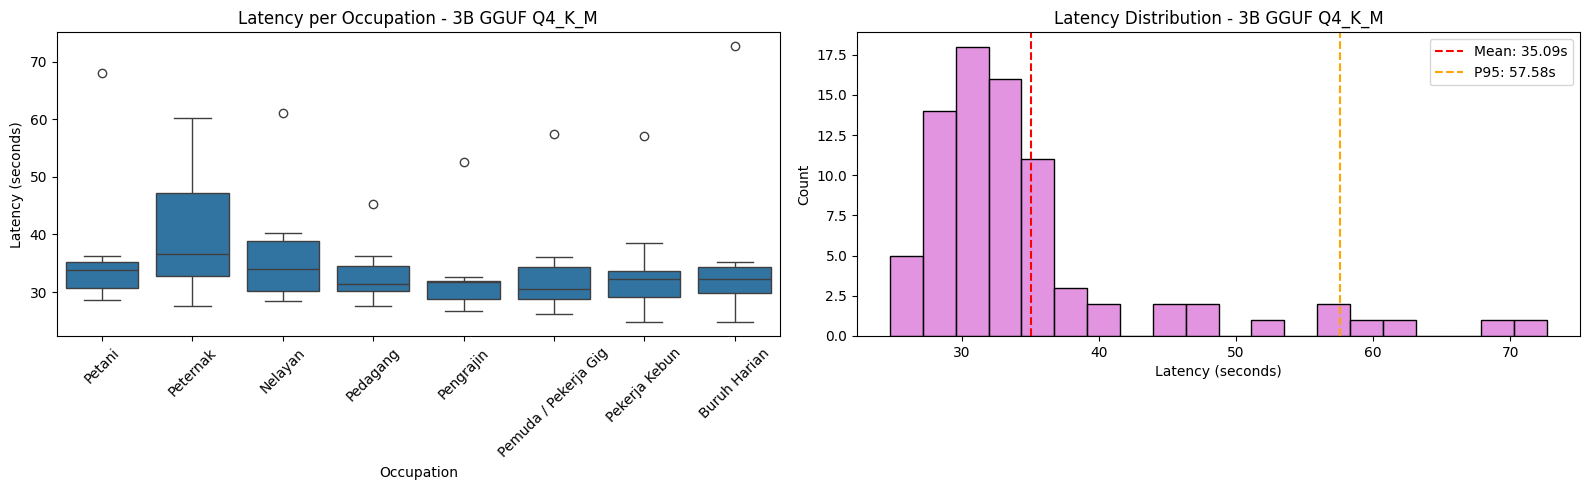

Latency Statistics:
  Mean   : 35.088s
  Median : 32.353s
  P95    : 57.581s
  Min    : 24.780s
  Max    : 72.681s
  Total  : 2807.0s for 80 requests


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

"""Visualisasi latency distribution untuk batch inference 3B"""

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=batch_df, x='occupation_label', y='latency_sec', ax=axes[0])
axes[0].set_title('Latency per Occupation - 3B GGUF Q4_K_M')
axes[0].set_xlabel('Occupation')
axes[0].set_ylabel('Latency (seconds)')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(data=batch_df, x='latency_sec', bins=20, ax=axes[1], color='orchid')
axes[1].set_title('Latency Distribution - 3B GGUF Q4_K_M')
axes[1].set_xlabel('Latency (seconds)')
axes[1].set_ylabel('Count')
axes[1].axvline(batch_df['latency_sec'].mean(), color='red', linestyle='--', label=f"Mean: {batch_df['latency_sec'].mean():.2f}s")
axes[1].axvline(batch_df['latency_sec'].quantile(0.95), color='orange', linestyle='--', label=f"P95: {batch_df['latency_sec'].quantile(0.95):.2f}s")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Latency Statistics:")
print(f"  Mean   : {batch_df['latency_sec'].mean():.3f}s")
print(f"  Median : {batch_df['latency_sec'].median():.3f}s")
print(f"  P95    : {batch_df['latency_sec'].quantile(0.95):.3f}s")
print(f"  Min    : {batch_df['latency_sec'].min():.3f}s")
print(f"  Max    : {batch_df['latency_sec'].max():.3f}s")
print(f"  Total  : {batch_df['latency_sec'].sum():.1f}s for {len(batch_df)} requests")

## Quality Assessment

In [48]:
def evaluate_explanation(row, occupation_profiles):
    """
    Automated quality heuristics untuk satu explanation result.
    Dimensi: relevance, language, length, clarity -> composite score (0.0 - 1.0).
    """
    text = row['explanation'].lower()
    occ_id = row['occupation_id']
    profile = occupation_profiles[occ_id]

    keywords = profile['domain_keywords']
    keyword_hits = sum(1 for kw in keywords if kw.lower().replace('_', ' ') in text)
    relevance_score = min(keyword_hits / 2.0, 1.0)

    text_len = len(row['explanation'])
    if 50 <= text_len <= 400:
        length_score = 1.0
    elif text_len < 50:
        length_score = text_len / 50.0
    else:
        length_score = max(0.0, 1.0 - (text_len - 400) / 300.0)

    indo_markers = ['ini', 'seperti', 'untuk', 'yang', 'dengan', 'dan', 'di', 'ke', 'dari', 'anda', 'kamu', 'bisa', 'akan', 'sudah', 'jadi', 'kalau', 'nanti', 'bapak', 'ibu']
    indo_hits = sum(1 for marker in indo_markers if f' {marker} ' in f' {text} ')
    language_score = min(indo_hits / 4.0, 1.0)

    clarity_markers = ['seperti', 'sama seperti', 'ibarat', 'misalnya', 'contohnya', 'bayangkan', 'kalau']
    clarity_hits = sum(1 for marker in clarity_markers if marker in text)
    clarity_score = min(clarity_hits / 2.0, 1.0)

    composite_score = (relevance_score * 0.30 + language_score * 0.25 + length_score * 0.20 + clarity_score * 0.25)

    return {
        'relevance_score': round(relevance_score, 2),
        'language_score': round(language_score, 2),
        'length_score': round(length_score, 2),
        'clarity_score': round(clarity_score, 2),
        'composite_score': round(composite_score, 2)
    }

"""Evaluate batch results"""
scores = batch_df.apply(lambda row: evaluate_explanation(row, occupation_profiles), axis=1, result_type='expand')
for col in scores.columns:
    batch_df[col] = scores[col]

print(f"3B GGUF Q4_K_M Quality Scores:")
print(f"  Composite   : {batch_df['composite_score'].mean():.3f} (std: {batch_df['composite_score'].std():.3f})")
print(f"  Relevance   : {batch_df['relevance_score'].mean():.3f}")
print(f"  Language    : {batch_df['language_score'].mean():.3f}")
print(f"  Length      : {batch_df['length_score'].mean():.3f}")
print(f"  Clarity     : {batch_df['clarity_score'].mean():.3f}")

3B GGUF Q4_K_M Quality Scores:
  Composite   : 0.835 (std: 0.109)
  Relevance   : 0.806
  Language    : 1.000
  Length      : 0.989
  Clarity     : 0.569


## Composite Score Heatmap

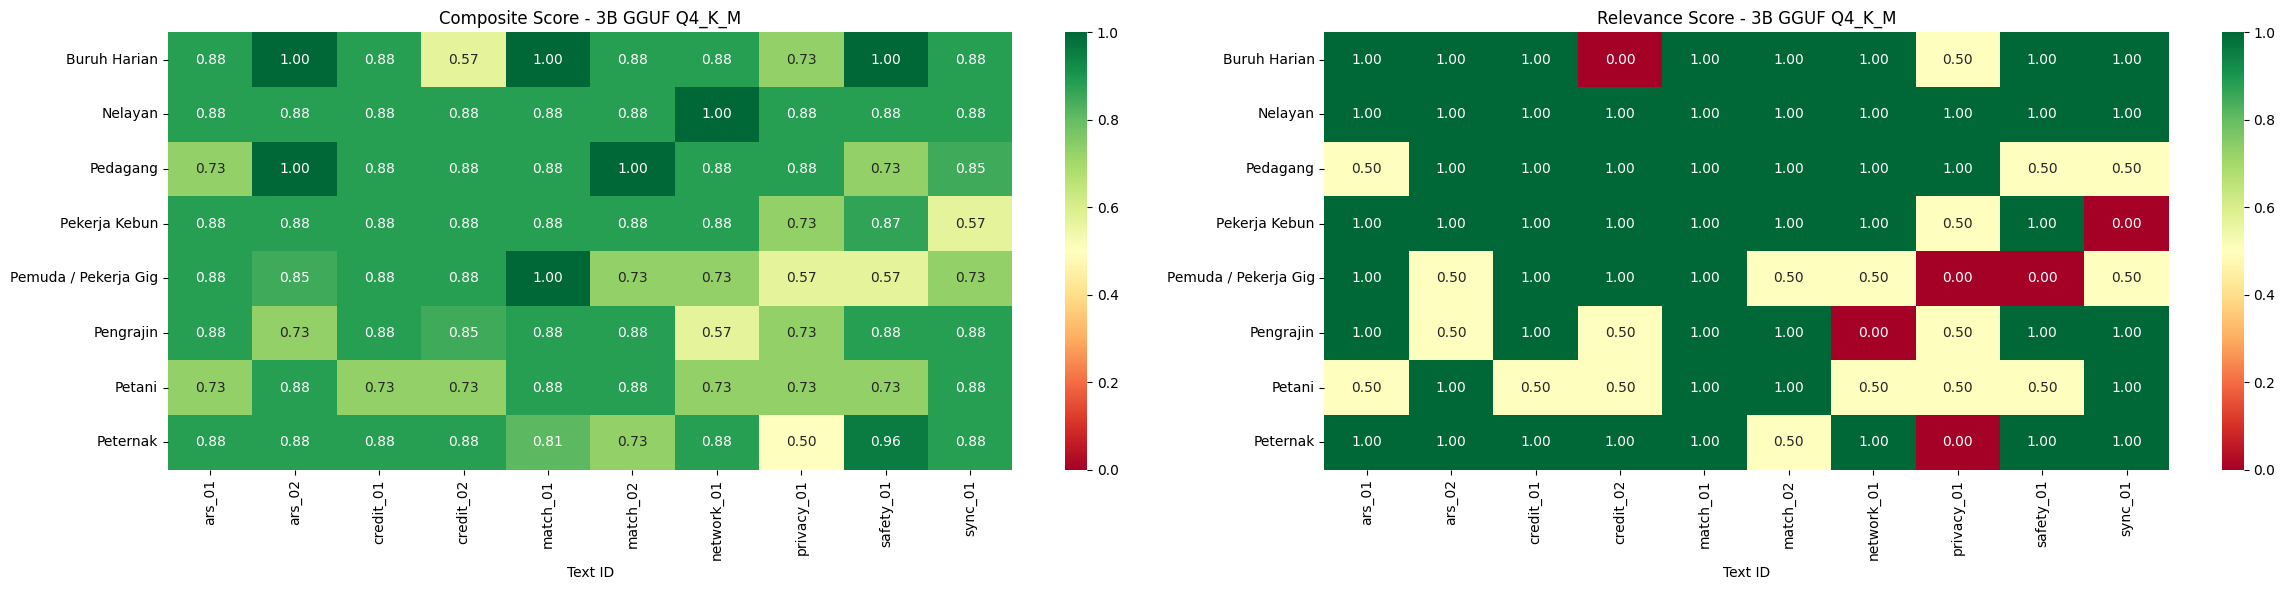


Per-Occupation Composite Scores:
                       mean    std   min   max
occupation_label                              
Buruh Harian          0.870  0.134  0.57  1.00
Nelayan               0.892  0.038  0.88  1.00
Pedagang              0.871  0.091  0.73  1.00
Pekerja Kebun         0.833  0.104  0.57  0.88
Pemuda / Pekerja Gig  0.782  0.141  0.57  1.00
Pengrajin             0.816  0.106  0.57  0.88
Petani                0.790  0.077  0.73  0.88
Peternak              0.828  0.130  0.50  0.96


In [49]:
"""Heatmap composite score: occupation x text_id untuk 3B GGUF Q4_K_M"""

fig, axes = plt.subplots(1, 2, figsize=(24, 6))

pivot_composite = batch_df.pivot_table(values='composite_score', index='occupation_label', columns='text_id', aggfunc='mean')
sns.heatmap(pivot_composite, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Composite Score - 3B GGUF Q4_K_M')
axes[0].set_xlabel('Text ID')
axes[0].set_ylabel('')

pivot_relevance = batch_df.pivot_table(values='relevance_score', index='occupation_label', columns='text_id', aggfunc='mean')
sns.heatmap(pivot_relevance, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Relevance Score - 3B GGUF Q4_K_M')
axes[1].set_xlabel('Text ID')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nPer-Occupation Composite Scores:")
occ_scores = batch_df.groupby('occupation_label')['composite_score'].agg(['mean', 'std', 'min', 'max']).round(3)
print(occ_scores.to_string())

## Sample Outputs

In [50]:
"""Preview output 3B untuk beberapa konsep dan occupation"""

preview_texts = ['credit_01', 'sync_01', 'ars_01', 'privacy_01', 'match_02']
preview_occupations = ['farmer', 'fisherman', 'trader', 'youth']

for text_id in preview_texts:
    subset = batch_df[
        (batch_df['text_id'] == text_id) &
        (batch_df['occupation_id'].isin(preview_occupations))
    ]
    if subset.empty:
        continue
    print(f"\n{'=' * 100}")
    print(f"[{text_id}] {subset.iloc[0]['concept_text'][:100]}...")
    print(f"{'=' * 100}")
    for _, row in subset.iterrows():
        score = row.get('composite_score', 'N/A')
        print(f"\n  {row['occupation_label']:22s} (score: {score})")
        print(f"  {row['explanation']}")


[credit_01] Credit scoring menganalisis pola transaksi, frekuensi pencatatan keuangan, dan jaringan sosial Anda ...

  Petani                 (score: 0.73)
  Seperti Pak Lurah yang tahu siapa di desa ini yang rajin bayar iuran dan siapa yang suka bantu tetangga panen, aplikasi credit scoring juga mengingat kerajinan Bapak mencatat transaksi keuangan secara rutin dan berinteraksi dengan banyak orang. Semakin baik pencatatan dan interaksi sosialnya, semakin tinggi skor kelayakan pinjaman yang bisa diajukan.

  Nelayan                (score: 0.88)
  Seperti juragan TPI yang tahu nelayan mana rajin melaut dan selalu bayar hutang solar tepat waktu, aplikasi ini juga mencatat pola transaksi, frekuensi pencatatan keuangan, dan jaringan sosial Anda. Semakin baik skor kelayakan pinjaman itu, semakin besar pinjaman yang bisa diajukan untuk perahu atau alat tangkap baru.

  Pedagang               (score: 0.88)
  Seperti Ibu, aplikasi ini lihat pola dagangan kita setiap hari. Jika banyak transaks

# Export

## Deployment Configuration

In [51]:
"""
Menyimpan deployment configuration untuk Contextual Explainer.
Primary: 3B GGUF Q4_K_M, Fallback: 1.5B GGUF Q4_K_M.
"""

deployment_config = {
    'feature_name': 'Contextual Explainer',
    'primary_model': {
        'name': config['model_3b_name'],
        'huggingface_id': config['model_3b_id'],
        'gguf_repo': config['model_3b_gguf_repo'],
        'gguf_filename': config['model_3b_gguf_filename'],
        'quantization': 'Q4_K_M',
        'estimated_size_mb': 2000,
        'parameters': '3B',
        'architecture': 'qwen2',
        'license': 'Apache-2.0'
    },
    'fallback_model': {
        'name': 'Qwen2.5-1.5B-Instruct',
        'huggingface_id': config['fallback_model_id'],
        'gguf_repo': config['fallback_gguf_repo'],
        'gguf_filename': config['fallback_gguf_filename'],
        'quantization': 'Q4_K_M',
        'estimated_size_mb': 1100,
        'parameters': '1.54B'
    },
    'lightweight_model': {
        'name': config['model_name'],
        'huggingface_id': config['model_id'],
        'gguf_repo': config['gguf_repo'],
        'gguf_filename': config['gguf_filename'],
        'quantization': 'Q4_K_M',
        'estimated_size_mb': 491,
        'parameters': '0.49B'
    },
    'generation': config['generation'],
    'gguf_params': config['gguf_params'],
    'system_prompt': system_prompt,
    'user_prompt_template': user_prompt_template,
    'occupation_categories': config['occupation_categories'],
    'occupation_labels': config['occupation_labels'],
    'occupation_profiles': {
        occ_id: {
            'label': profile['label'],
            'domain_keywords': profile['domain_keywords'],
            'typical_context': profile['typical_context'],
            'explanation_style': profile['explanation_style'],
            'example_concept': profile['example_concept'],
            'example_explanation': profile['example_explanation']
        }
        for occ_id, profile in occupation_profiles.items()
    },
    'evaluation_summary': {
        'primary_model_avg_composite': round(batch_df['composite_score'].mean(), 3),
        'primary_model_avg_latency_cpu_sec': round(batch_df['latency_sec'].mean(), 3),
        'primary_model_p95_latency_cpu_sec': round(batch_df['latency_sec'].quantile(0.95), 3),
        'test_matrix_size': len(test_matrix_df)
    },
    'metadata': {
        'created_at': datetime.now().isoformat(),
        'notebook': 'ai-dialect-translator.ipynb',
        'feature': 'Contextual Explainer'
    }
}

deployment_json_path = f'{models_path}/contextual_explainer_params.json'
with open(deployment_json_path, 'w', encoding='utf-8') as f:
    json.dump(deployment_config, f, indent=2, ensure_ascii=False)

print(f"Saved: {deployment_json_path}")
print(f"\nPrimary Model  : {deployment_config['primary_model']['name']} ({deployment_config['primary_model']['quantization']}, ~{deployment_config['primary_model']['estimated_size_mb']}MB)")
print(f"Fallback Model : {deployment_config['fallback_model']['name']} ({deployment_config['fallback_model']['quantization']}, ~{deployment_config['fallback_model']['estimated_size_mb']}MB)")
print(f"Lightweight    : {deployment_config['lightweight_model']['name']} ({deployment_config['lightweight_model']['quantization']}, ~{deployment_config['lightweight_model']['estimated_size_mb']}MB)")
print(f"Composite Score: {deployment_config['evaluation_summary']['primary_model_avg_composite']}")

Saved: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/contextual_explainer_params.json

Primary Model  : Qwen2.5-3B-Instruct (Q4_K_M, ~2000MB)
Fallback Model : Qwen2.5-1.5B-Instruct (Q4_K_M, ~1100MB)
Lightweight    : Qwen2.5-0.5B-Instruct (Q4_K_M, ~491MB)
Composite Score: 0.835


# Inference Pipeline Guide

**Required Files:**
- `contextual_explainer_params.json` - Configuration (prompts, occupation profiles, generation params)
- `qwen2.5-3b-instruct-q4_k_m.gguf` - Model file (~2GB, download dari HuggingFace)

## Setup

In [52]:
import os
import re
import json
import time
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

print("Imports loaded successfully")

Imports loaded successfully


In [53]:
MODELS_PATH = '/content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator'
CONFIG_FILENAME = 'contextual_explainer_params.json'
GGUF_SUBFOLDER = '3b'
GGUF_FILENAME = 'qwen2.5-3b-instruct-q4_k_m.gguf'
GGUF_REPO = 'Qwen/Qwen2.5-3B-Instruct-GGUF'

config_path = os.path.join(MODELS_PATH, CONFIG_FILENAME)
gguf_folder = os.path.join(MODELS_PATH, GGUF_SUBFOLDER)
gguf_path = os.path.join(gguf_folder, GGUF_FILENAME)

print(f"Config path: {config_path}")
print(f"GGUF path: {gguf_path}")

Config path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/contextual_explainer_params.json
GGUF path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/ai-dialect-translator/3b/qwen2.5-3b-instruct-q4_k_m.gguf


In [54]:
def clean_output(text):
    """
    Post processing untuk membersihkan artefak prompt dari output model.
    Menghapus prefix 'Output:', 'Input:', tanda kutip pembungkus, dan whitespace berlebih.
    """
    cleaned = text.strip()
    
    cleaned = re.sub(r'^(Output|Input)\s*:\s*', '', cleaned, flags=re.IGNORECASE)
    
    if (cleaned.startswith('"') and cleaned.endswith('"')) or (cleaned.startswith("'") and cleaned.endswith("'")):
        cleaned = cleaned[1:-1].strip()
    
    cleaned = re.sub(r'^(Output|Input)\s*:\s*', '', cleaned, flags=re.IGNORECASE)
    
    if (cleaned.startswith('"') and cleaned.endswith('"')) or (cleaned.startswith("'") and cleaned.endswith("'")):
        cleaned = cleaned[1:-1].strip()
    
    return cleaned

print("clean_output() helper function defined")

clean_output() helper function defined


## Model Loading

In [55]:
with open(config_path, 'r', encoding='utf-8') as f:
    deployment_params = json.load(f)

print(f"Configuration loaded: {CONFIG_FILENAME}")
print(f"  - Occupation categories: {len(deployment_params['occupation_categories'])}")
print(f"  - System prompt length: {len(deployment_params['system_prompt'])} chars")

Configuration loaded: contextual_explainer_params.json
  - Occupation categories: 8
  - System prompt length: 328 chars


In [56]:
os.makedirs(gguf_folder, exist_ok=True)

if os.path.exists(gguf_path):
    file_size_mb = os.path.getsize(gguf_path) / (1024 * 1024)
    print(f"GGUF model found: {GGUF_FILENAME} ({file_size_mb:.1f} MB)")
else:
    print(f"Downloading {GGUF_FILENAME} from {GGUF_REPO}...")
    hf_hub_download(
        repo_id=GGUF_REPO,
        filename=GGUF_FILENAME,
        local_dir=gguf_folder,
        local_dir_use_symlinks=False
    )
    file_size_mb = os.path.getsize(gguf_path) / (1024 * 1024)
    print(f"Downloaded: {GGUF_FILENAME} ({file_size_mb:.1f} MB)")

gguf_params = deployment_params['gguf_params']
llm = Llama(
    model_path=gguf_path,
    n_ctx=gguf_params['n_ctx'],
    n_threads=gguf_params['n_threads'],
    n_batch=gguf_params['n_batch'],
    verbose=gguf_params['verbose'],
    n_gpu_layers=0
)
print(f"GGUF model loaded and ready for inference")

GGUF model found: qwen2.5-3b-instruct-q4_k_m.gguf (2007.4 MB)


llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


GGUF model loaded and ready for inference


## Pipeline Function

In [57]:
def contextual_explain(occupation_id, concept_text, llm_instance, deployment_params):
    """
    Menjelaskan konsep teknis dengan bahasa yang sesuai occupation pengguna.

    Parameters:
        occupation_id (str): ID occupation (misal 'farmer', 'fisherman')
        concept_text (str): Konsep teknis yang perlu dijelaskan
        llm_instance: Instance Llama (llama-cpp-python)
        deployment_params (dict): Configuration dari contextual_explainer_params.json

    Returns:
        dict: explanation, occupation_label, latency_sec
    """
    profile = deployment_params['occupation_profiles'][occupation_id]
    sys_prompt = deployment_params['system_prompt']
    user_tmpl = deployment_params['user_prompt_template']
    gen = deployment_params['generation']

    user_msg = user_tmpl.format(
        occupation_label=profile['label'],
        typical_context=profile['typical_context'],
        domain_keywords=', '.join(profile['domain_keywords'][:5]),
        example_concept=profile['example_concept'],
        example_explanation=profile['example_explanation'],
        concept_text=concept_text
    )

    messages = [
        {'role': 'system', 'content': sys_prompt},
        {'role': 'user', 'content': user_msg}
    ]

    start_time = time.time()
    response = llm_instance.create_chat_completion(
        messages=messages,
        max_tokens=gen['max_new_tokens'],
        temperature=gen['temperature'],
        top_p=gen['top_p'],
        top_k=gen['top_k'],
        repeat_penalty=gen['repetition_penalty']
    )
    latency = time.time() - start_time

    raw_text = response['choices'][0]['message']['content'].strip()
    cleaned_text = clean_output(raw_text)

    return {
        'explanation': cleaned_text,
        'occupation_label': deployment_params['occupation_labels'][occupation_id],
        'latency_sec': round(latency, 3)
    }

print("contextual_explain() pipeline function defined")

contextual_explain() pipeline function defined


## Demo


In [58]:
demo_cases = [
    ('farmer', 'Credit scoring menganalisis pola transaksi dan frekuensi pencatatan keuangan untuk menentukan skor kelayakan pinjaman.'),
    ('fisherman', 'Mode offline memungkinkan Anda tetap menggunakan aplikasi tanpa internet. Data disimpan lokal dan tersinkronisasi otomatis.'),
    ('youth', 'Verifikasi dua langkah menambah lapisan keamanan dengan konfirmasi SMS atau sidik jari selain password.'),
    ('livestock_owner', 'Dashboard keuangan menampilkan ringkasan pendapatan, pengeluaran, dan tren bulanan dalam bentuk grafik sederhana.'),
    ('trader', 'Algoritma rekomendasi mempelajari pola transaksi Anda untuk menyarankan waktu terbaik menjual produk.'),
    ('plantation_worker', 'Proyeksi keuangan menggunakan data historis untuk memperkirakan pendapatan di bulan-bulan mendatang.'),
    ('craftsman', 'Fitur jaringan sosial menghubungkan Anda dengan pengguna lain untuk berbagi informasi harga pasar dan peluang kerja.'),
    ('daily_laborer', 'Enkripsi end-to-end melindungi data keuangan Anda. Data dienkripsi di perangkat sebelum dikirim ke server.')
]

print("Contextual Explainer - Standalone Pipeline Demo")
print(f"Model: {GGUF_FILENAME}")
print("=" * 100)

for occ_id, concept in demo_cases:
    result = contextual_explain(occ_id, concept, llm, deployment_params)
    print(f"\n[{result['occupation_label']:22s}] ({result['latency_sec']}s)")
    print(f"  Concept    : {concept[:80]}...")
    print(f"  Explanation: {result['explanation']}")

Contextual Explainer - Standalone Pipeline Demo
Model: qwen2.5-3b-instruct-q4_k_m.gguf

[Petani                ] (67.298s)
  Concept    : Credit scoring menganalisis pola transaksi dan frekuensi pencatatan keuangan unt...
  Explanation: Penjelasan: "Seperti Pak Lurah yang tahu siapa di desa ini yang rajin mencatat hasil panen dan bayar cicilan tepat waktu. Aplikasi ini juga mengingat kerajinan Bapak dalam mencatat transaksi keuangan dan frekuensinya, sehingga bisa menentukan skor kelayakan pinjaman."

[Nelayan               ] (55.666s)
  Concept    : Mode offline memungkinkan Anda tetap menggunakan aplikasi tanpa internet. Data d...
  Explanation: Penjelasan: "Seperti juragan TPI yang bisa melaut dan menjual tangkapan meski tidak punya internet, aplikasi ini memungkinkan nelayan untuk tetap menggunakan fitur penting tanpa koneksi. Data hasil tangkapan disimpan di perahu (seperti komputer lokal) dan otomatis tersinkronisasi ke sistem utama saat kembali dengan jala baru."

[Pemuda / Peke

In [ ]:
"""Install dependency untuk upload artifact ke Hugging Face Hub."""
!pip install huggingface_hub


In [ ]:
"""Login ke Hugging Face Hub dari notebook."""
from huggingface_hub import notebook_login, HfApi

notebook_login()


In [ ]:
"""Upload contextual_explainer_params.json ke Hugging Face Hub."""
import os
from huggingface_hub import HfApi

HF_REPO_ID = 'your-username/your-repo-name'
HF_REPO_PRIVATE = True
HF_COMMIT_MESSAGE = 'Add contextual_explainer_params.json'

if 'models_path' not in globals():
    raise RuntimeError('models_path belum tersedia. Jalankan sel setup path terlebih dahulu.')

if not HF_REPO_ID or 'your-username' in HF_REPO_ID or 'your-repo-name' in HF_REPO_ID:
    raise ValueError('HF_REPO_ID masih placeholder. Isi dengan repo Hugging Face Anda.')

if not os.path.isdir(models_path):
    raise FileNotFoundError(f'models_path tidak ditemukan: {models_path}')

local_filename = 'contextual_explainer_params.json'
local_file_path = os.path.join(models_path, local_filename)

if not os.path.isfile(local_file_path):
    raise FileNotFoundError(f'File tidak ditemukan: {local_file_path}')

api = HfApi()
HfApi().create_repo(repo_id=HF_REPO_ID, private=HF_REPO_PRIVATE, exist_ok=True)

upload_result = api.upload_file(
    path_or_fileobj=local_file_path,
    path_in_repo=local_filename,
    repo_id=HF_REPO_ID,
    commit_message=HF_COMMIT_MESSAGE
)

print(f'Upload success: {local_file_path}')
print(f'Repository: https://huggingface.co/{HF_REPO_ID}')
print(f'Commit info: {upload_result}')
